In [1]:
#Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from google.colab import files

# Load CSV file
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sampleSubmission.csv')

## Data Cleaning

In [3]:
#Checking the data head
train.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
1,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
2,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
3,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no
4,MA,121,area_code_510,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,no


In [4]:
#checking the data head
train.shape

(4250, 20)

In [5]:
#Getting to know the data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          4250 non-null   object 
 1   account_length                 4250 non-null   int64  
 2   area_code                      4250 non-null   object 
 3   international_plan             4250 non-null   object 
 4   voice_mail_plan                4250 non-null   object 
 5   number_vmail_messages          4250 non-null   int64  
 6   total_day_minutes              4250 non-null   float64
 7   total_day_calls                4250 non-null   int64  
 8   total_day_charge               4250 non-null   float64
 9   total_eve_minutes              4250 non-null   float64
 10  total_eve_calls                4250 non-null   int64  
 11  total_eve_charge               4250 non-null   float64
 12  total_night_minutes            4250 non-null   f

In [6]:
#checking the data head for test
test.head()

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,AL,118,area_code_510,yes,no,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,IA,62,area_code_415,no,no,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,VT,93,area_code_510,no,no,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,NE,174,area_code_415,no,no,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [7]:
test = test.drop(columns=['Unnamed: 0'], errors='ignore')

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             750 non-null    int64  
 1   state                          750 non-null    object 
 2   account_length                 750 non-null    int64  
 3   area_code                      750 non-null    object 
 4   international_plan             750 non-null    object 
 5   voice_mail_plan                750 non-null    object 
 6   number_vmail_messages          750 non-null    int64  
 7   total_day_minutes              750 non-null    float64
 8   total_day_calls                750 non-null    int64  
 9   total_day_charge               750 non-null    float64
 10  total_eve_minutes              750 non-null    float64
 11  total_eve_calls                750 non-null    int64  
 12  total_eve_charge               750 non-null    flo

In [9]:
train.describe()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
count,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000
mean,100.236235,7.631765,180.259600,99.907294,30.644682,200.173906,100.176471,17.015012,200.527882,99.839529,9.023892,10.256071,4.426353,2.769654,1.559059
std,39.698401,13.439882,54.012373,19.850817,9.182096,50.249518,19.908591,4.271212,50.353548,20.093220,2.265922,2.760102,2.463069,0.745204,1.311434
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.325000,87.000000,24.365000,165.925000,87.000000,14.102500,167.225000,86.000000,7.522500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,0.000000,180.450000,100.000000,30.680000,200.700000,100.000000,17.060000,200.450000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,16.000000,216.200000,113.000000,36.750000,233.775000,114.000000,19.867500,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000
max,243.000000,52.000000,351.500000,165.000000,59.760000,359.300000,170.000000,30.540000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [10]:
test.shape

(750, 20)

In [11]:
#checking for chrun count
train['churn'].value_counts()

,count
churn,
no,3652
yes,598


In [12]:
# checking for chrun proportion
train['churn'].value_counts(normalize=True)

,proportion
churn,
no,0.859294
yes,0.140706


In [13]:
#Checking for missing values
train.isnull().sum()

,0
state,0
account_length,0
area_code,0
international_plan,0
voice_mail_plan,0
number_vmail_messages,0
total_day_minutes,0
total_day_calls,0
total_day_charge,0
total_eve_minutes,0


In [14]:
#Checking for missing value
test.isnull().sum()

,0
id,0
state,0
account_length,0
area_code,0
international_plan,0
voice_mail_plan,0
number_vmail_messages,0
total_day_minutes,0
total_day_calls,0
total_day_charge,0


In [15]:
# Map Yes/No to 1/0
binary_cols = ['international_plan', 'voice_mail_plan', 'churn']

for cols in binary_cols:
  if cols in train.columns:
    train[cols] = train[cols].map({'yes': 1, 'no': 0})

In [16]:
train.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
1,NJ,137,area_code_415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
2,OH,84,area_code_408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
3,OK,75,area_code_415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
4,MA,121,area_code_510,0,1,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0


In [17]:
test['international_plan'].unique()
test['voice_mail_plan'].unique()

array(['yes', 'no'], dtype=object)

In [18]:
test['international_plan'] = test['international_plan'].map({'yes':1, 'no':0})
test['voice_mail_plan'] = test['voice_mail_plan'].map({'yes':1, 'no':0})

In [19]:
test.head()

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,KS,128,area_code_415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,AL,118,area_code_510,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,IA,62,area_code_415,0,0,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,VT,93,area_code_510,0,0,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,NE,174,area_code_415,0,0,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [20]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             750 non-null    int64  
 1   state                          750 non-null    object 
 2   account_length                 750 non-null    int64  
 3   area_code                      750 non-null    object 
 4   international_plan             750 non-null    int64  
 5   voice_mail_plan                750 non-null    int64  
 6   number_vmail_messages          750 non-null    int64  
 7   total_day_minutes              750 non-null    float64
 8   total_day_calls                750 non-null    int64  
 9   total_day_charge               750 non-null    float64
 10  total_eve_minutes              750 non-null    float64
 11  total_eve_calls                750 non-null    int64  
 12  total_eve_charge               750 non-null    flo

## Feature Engineering

In [21]:
# Total minutes across all periods
train['total_minutes'] = train['total_day_minutes'] + train['total_eve_minutes'] + train['total_night_minutes'] + train['total_intl_minutes']
test['total_minutes'] = test['total_day_minutes'] + test['total_eve_minutes'] + test['total_night_minutes'] + test['total_intl_minutes']


In [22]:
# Total charges across all periods
train['total_charges'] = train['total_day_charge'] + train['total_eve_charge'] + train['total_night_charge'] + train['total_intl_charge']
test['total_charges'] = test['total_day_charge'] + test['total_eve_charge'] + test['total_night_charge'] + test['total_intl_charge']

In [23]:
# Average call duration in each period
train['avg_day_call'] = train['total_day_minutes'] / train['total_day_calls'].replace(0, np.nan)
train['avg_eve_call'] = train['total_eve_minutes'] / train['total_eve_calls'].replace(0, np.nan)
train['avg_night_call'] = train['total_night_minutes'] / train['total_night_calls'].replace(0, np.nan)
train['avg_intl_call'] = train['total_intl_minutes'] / train['total_intl_calls'].replace(0, np.nan)

Customer Service Calls vs Churn

In [24]:
# Churn rate vs customer service calls
cs_churn = train.groupby('number_customer_service_calls')['churn'].mean().reset_index()
cs_churn

,number_customer_service_calls,churn
0,0,0.109481
1,1,0.108924
2,2,0.107709
3,3,0.112903
4,4,0.440191
5,5,0.604938
6,6,0.678571
7,7,0.538462
8,8,0.500000
9,9,1.000000


Customers who contact customer service more than 3 times are significantly more likely to churn. Which indicate unresolved service issues are a primary driver of customer loss.

Plan-Based Churn Analysis

In [25]:
# Churn rate vs voicemail plan
train.groupby('voice_mail_plan')['churn'].mean()

,churn
voice_mail_plan,
0,0.164436
1,0.073741


Customers without a voicemail plan have a significantly higher churn rate (16.4% vs 7.4%), suggesting that value-added services improve customer retention.

In [26]:
# Churn rate vs international plan
train.groupby('international_plan')['churn'].mean()

,churn
international_plan,
0,0.111832
1,0.421717


Customers subscribed to international plans exhibit a significantly higher churn rate (42%) compared to non-subscribers (11%), indicating pricing or service dissatisfaction in international calls.

Tenure Analysis

In [27]:
# Create tenure buckets
train['tenure_bucket'] = pd.cut(train['account_length'], bins=[0,50,100,150,200], labels=['0-50','51-100','101-150','151-200'])
tenure_churn = train.groupby('tenure_bucket')['churn'].mean()
tenure_churn

/tmp/ipykernel_1691/84912727.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = train.groupby('tenure_bucket')['churn'].mean()


,churn
tenure_bucket,
0-50,0.125280
51-100,0.138211
101-150,0.144600
151-200,0.144928


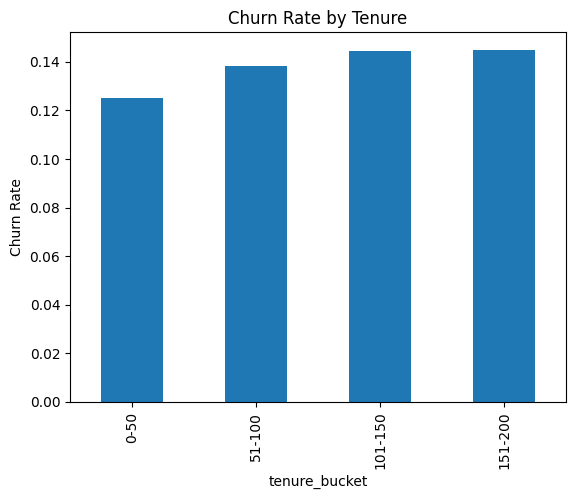

In [28]:
tenure_churn.plot(kind='bar')
plt.title("Churn Rate by Tenure")
plt.ylabel("Churn Rate")
plt.show()

This is a weak trend, not a strong driver for chruning

Revenue Impact of Churn

In [30]:
#Total Revenue
total_revenue = train['total_charges'].sum()
total_revenue

np.float64(252676.27)

In [31]:
# Revenue lost due to churn
total_revenue_lost = train[train['churn']==1]['total_charges'].sum()
total_revenue_lost

np.float64(39188.240000000005)

In [32]:
revenue_loss_pct = (total_revenue_lost / total_revenue) * 100
revenue_loss_pct

np.float64(15.509268044838562)

Approximately 16% of total revenue is lost due to customer churn.

In [33]:
#Average Revenue per Churned Customer
avg_churn_revenue = train[train['churn']==1]['total_charges'].mean()
avg_churn_revenue

np.float64(65.5321739130435)

Average Revenue per Churned Customer 65.53

In [34]:
#Compare With Non-Churn Customers
train.groupby('churn')['total_charges'].mean()

,total_charges
churn,
0,58.457840
1,65.532174


Customers who churn actually spend MORE than those who stay.

In [35]:
# High value Customer
high_value_threshold = train['total_charges'].median()

high_value_churn = train[
    (train['churn'] == 1) &
    (train['total_charges'] > high_value_threshold)
]

high_value_churn['total_charges'].sum()

np.float64(27201.14)

27,201 comes from high-value customers

In [36]:
high_value_pct = (27201.14 / 39188.24) * 100
high_value_pct

69.41148671131953

Approximately 69% of total revenue loss is coming from high-value customers.

Churned customers account for approximately $39,188 in lost revenue, representing 16% of total revenue. Notably, a significant portion of this loss comes from high-value customers, indicating a critical need for targeted retention strategies.

Geographical Churn

In [37]:
# Churn by state
state_churn = train.groupby('state')['churn'].mean().sort_values(ascending=False)
state_churn.head(10)

,churn
state,
NJ,0.270833
CA,0.256410
WA,0.225000
MD,0.220930
MT,0.212500
OK,0.205128
NV,0.204819
SC,0.194444
TX,0.193878


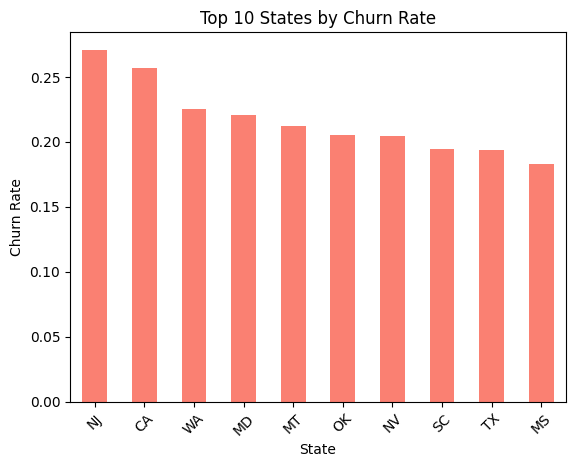

In [38]:
top10_state_churn = state_churn.head(10)  # select top 10
top10_state_churn.plot(kind='bar', color='salmon')
plt.title("Top 10 States by Churn Rate")
plt.ylabel("Churn Rate")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.show()

Correlation

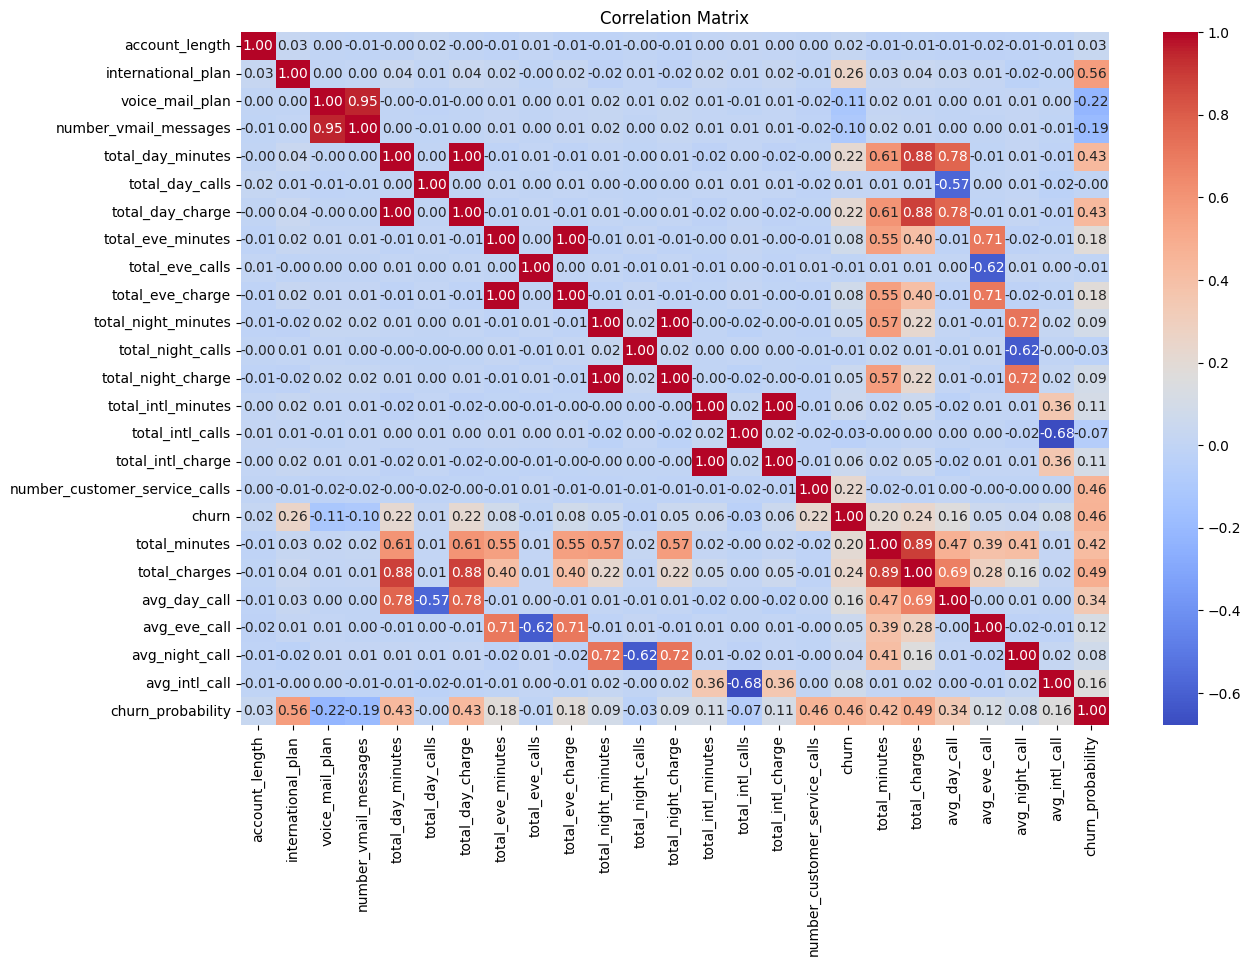

In [73]:
# Select only numeric columns
numeric_train = train.select_dtypes(include=[np.number])

# Plot heatmap using only numeric data
plt.figure(figsize=(14,9))
sns.heatmap(numeric_train.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Customer Segmentation

High Value Customers

In [40]:
median_revenue = train['total_charges'].median()
train['high_value'] = train['total_charges'] > median_revenue

High Churn Risk Customers

In [41]:
train['high_risk'] = train['churn'] == 1

In [42]:
#Combine to create a segment
def segment_customer(row):
    if row['high_value'] and row['high_risk']:
        return 'High Value - High Risk'
    elif row['high_value'] and not row['high_risk']:
        return 'High Value - Low Risk'
    elif not row['high_value'] and row['high_risk']:
        return 'Low Value - High Risk'
    else:
        return 'Low Value - Low Risk'

train['segment'] = train.apply(segment_customer, axis=1)

In [43]:
#Validate the Segments
train['segment'].value_counts()

,count
segment,
Low Value - Low Risk,1888
High Value - Low Risk,1764
High Value - High Risk,361
Low Value - High Risk,237


In [44]:
#Check average revenue and churn rate per segment
segment_summary = train.groupby('segment').agg(
    total_customers=('churn','count'),
    churn_rate=('churn','mean'),
    avg_revenue=('total_charges','mean')
).reset_index()

segment_summary

,segment,total_customers,churn_rate,avg_revenue
0,High Value - High Risk,361,1.0,75.349418
1,High Value - Low Risk,1764,0.0,66.089144
2,Low Value - High Risk,237,1.0,50.578481
3,Low Value - Low Risk,1888,0.0,51.327744


Insight
- High-value customers who churn contribute the largest share of revenue loss
- **Majority** of customers (High Value - Low Risk & Low Value - Low Risk) are stable retention should be targeted to them

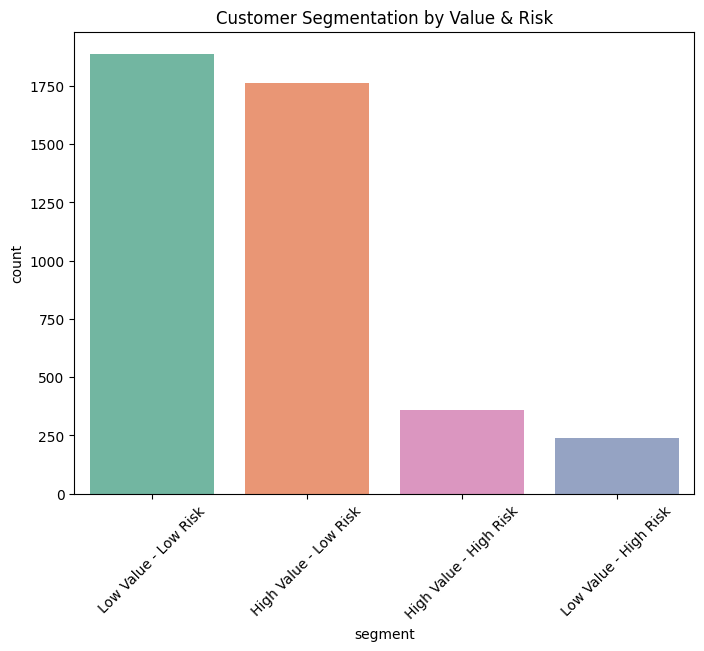

In [45]:
plt.figure(figsize=(8,6))
sns.countplot(data=train, x='segment', order=train['segment'].value_counts().index, palette='Set2', hue='segment', )
plt.title("Customer Segmentation by Value & Risk")
plt.xticks(rotation=45)
plt.show()

Insight
1. High Value - High Risk: Churned customers
2. High Value - Low Risk: Already loyal customers
3. Low Value - High Risk: Less revenue, churned customers
4. Low Value - Low Risk: Not churning customers

## Prediction Model

In [46]:
# Drop non-useful columns (like state for now, we can encode later if needed)
X = train.drop(['churn', 'state','high_risk', 'segment', 'high_value'], axis=1, errors='ignore' )
y = train['churn']

In [48]:
X = pd.get_dummies(X, drop_first=True)

In [49]:
# Test train spilt
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 2. Handle missing values
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

In [50]:
# Scale the data for logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [51]:
#Train the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [52]:
# Evaluate the Model

#Predicitions
y_pred = model.predict(X_val_scaled)
y_proba = model.predict_proba(X_val_scaled)[:, 1]

In [53]:
#metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       730
           1       0.48      0.21      0.29       120

    accuracy                           0.86       850
   macro avg       0.68      0.59      0.61       850
weighted avg       0.82      0.86      0.83       850



In [54]:
confusion_matrix(y_val, y_pred)

array([[703,  27],
       [ 95,  25]])

In [55]:
roc_auc_score(y_val, y_proba)

np.float64(0.7890867579908676)

In [56]:
#Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

feature_importance

,feature,coefficient
16,number_customer_service_calls,0.744424
1,international_plan,0.650049
3,number_vmail_messages,0.531847
22,avg_intl_call,0.313975
18,total_charges,0.245508
17,total_minutes,0.230906
4,total_day_minutes,0.197075
6,total_day_charge,0.194224
9,total_eve_charge,0.144752
7,total_eve_minutes,0.143008


A predictive churn model was developed with an ROC-AUC of 0.79, identifying key drivers such as customer service interactions, pricing, and usage behavior.
The analysis revealed that high-value customers with frequent service complaints are at the highest risk of churn, highlighting the need for targeted retention strategies.

## Recall

In [65]:
y_pred_new = (y_proba > 0.3).astype(int)

In [66]:
#Evaluate
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_val, y_pred_new))
confusion_matrix(y_val, y_pred_new)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       730
           1       0.40      0.42      0.41       120

    accuracy                           0.83       850
   macro avg       0.65      0.66      0.65       850
weighted avg       0.83      0.83      0.83       850



array([[655,  75],
       [ 70,  50]])

In [67]:
thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred_temp = (y_proba > t).astype(int)
    from sklearn.metrics import recall_score
    recall = recall_score(y_val, y_pred_temp)
    print(f"Threshold: {t:.1f} | Recall: {recall:.2f}")

Threshold: 0.1 | Recall: 0.79
Threshold: 0.2 | Recall: 0.62
Threshold: 0.3 | Recall: 0.42
Threshold: 0.4 | Recall: 0.28
Threshold: 0.5 | Recall: 0.21
Threshold: 0.6 | Recall: 0.15
Threshold: 0.7 | Recall: 0.12
Threshold: 0.8 | Recall: 0.08


In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [70]:
# Re-evaluate
y_proba = model.predict_proba(X_val_scaled)[:,1]
y_pred = (y_proba > 0.3).astype(int)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.54      0.69       730
           1       0.24      0.87      0.37       120

    accuracy                           0.58       850
   macro avg       0.60      0.70      0.53       850
weighted avg       0.86      0.58      0.64       850



In [76]:
final_df = train.copy()

# Keep important columns
final_df = final_df[[
    'churn',
    'churn_probability',
    'account_length',
    'international_plan',
    'voice_mail_plan',
    'number_customer_service_calls',
    'total_charges',
    'total_minutes'
]]

# Save to CSV
final_df.to_csv('churn_data.csv', index=False)